# CMPINAM — Explorando Dados (sem modelos)
## O dinheiro torna as pessoas mais felizes?

Este notebook é **introdutório e prático**: vamos trabalhar com dados, **sem treinar modelos** ainda.

**Objetivos de aprendizagem**
- Transformar uma pergunta em uma investigação com dados
- Criar/organizar um conjunto de dados (dataset)
- Fazer uma análise exploratória (EDA): estatísticas simples e visualização
- Discutir **padrões**, **tendências**, **outliers** e **limitações**

> **Importante:** aqui não faremos `fit()` nem usaremos algoritmos de regressão/classificação.


## 1) Definindo o problema

**Pergunta de investigação**
> “O dinheiro torna as pessoas mais felizes?”

Para investigar isso, vamos precisar de pelo menos duas variáveis:
- **PIB per capita** (indicador de riqueza média do país)
- **Satisfação com a vida** (uma medida de bem-estar)

### Como vamos trabalhar aqui?
Como primeiro passo, usaremos um **dataset pequeno e didático** (criado por nós) para praticar o processo.

Depois, quando você quiser, dá para substituir por dados reais (OCDE/FMI), mantendo a mesma estrutura do notebook.


## 2) Preparando o ambiente

Vamos usar:
- `pandas` para tabelas
- `matplotlib` para gráficos

Execute a célula abaixo:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuração opcional: mostrar mais colunas/linhas no pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)


## 3) Criando um dataset didático

Vamos criar um dataset bem pequeno com:
- País
- PIB per capita (USD — valor aproximado só para fins didáticos)
- Satisfação com a vida (0 a 10)

> Você pode trocar/expandir os valores depois.


In [2]:
data = {
    "Country": ["Brasil", "EUA", "Alemanha", "Chile", "Índia", "Austrália", "Coreia do Sul", "Hungria"],
    "GDP_per_capita": [9000, 65000, 52000, 16000, 3000, 57000, 33000, 18000],
    "Life_satisfaction": [6.5, 7.2, 7.0, 6.8, 5.2, 7.3, 6.4, 6.0],
}

df = pd.DataFrame(data)
df


,Country,GDP_per_capita,Life_satisfaction
0,Brasil,9000,6.5
1,EUA,65000,7.2
2,Alemanha,52000,7.0
3,Chile,16000,6.8
4,Índia,3000,5.2
5,Austrália,57000,7.3
6,Coreia do Sul,33000,6.4
7,Hungria,18000,6.0


### 3.1) Salvando e lendo como CSV (simulando dados “vindos de fora”)

Isso ajuda os alunos a entenderem o fluxo real: dados geralmente chegam em arquivo.

Execute:


In [3]:
csv_path = "life_satisfaction_demo.csv"
df.to_csv(csv_path, index=False)
print("Arquivo salvo em:", csv_path)

df_csv = pd.read_csv(csv_path)
df_csv.head()


Arquivo salvo em: life_satisfaction_demo.csv


,Country,GDP_per_capita,Life_satisfaction
0,Brasil,9000,6.5
1,EUA,65000,7.2
2,Alemanha,52000,7.0
3,Chile,16000,6.8
4,Índia,3000,5.2


## 4) Inspeção inicial dos dados (EDA básica)

Nesta seção, vamos responder:
- Quantas linhas/colunas existem?
- Que tipos de dados temos?
- Há valores faltantes?


In [4]:
df_csv.shape


(8, 3)

In [5]:
df_csv.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            8 non-null      object 
 1   GDP_per_capita     8 non-null      int64  
 2   Life_satisfaction  8 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes


In [6]:
df_csv.isna().sum()


Country              0
GDP_per_capita       0
Life_satisfaction    0
dtype: int64

## 5) Estatísticas descritivas

Vamos olhar para:
- média, mínimo, máximo
- distribuição geral dos valores

Execute:


In [7]:
df_csv.describe()


,GDP_per_capita,Life_satisfaction
count,8.000000,8.000000
mean,31625.000000,6.550000
std,23712.187945,0.696932
min,3000.000000,5.200000
25%,14250.000000,6.300000
50%,25500.000000,6.650000
75%,53250.000000,7.050000
max,65000.000000,7.300000


### 5.1) Ordenando os países por PIB per capita

Isso ajuda a observar padrões e comparar extremos.

Execute:


In [8]:
df_sorted = df_csv.sort_values("GDP_per_capita")
df_sorted


,Country,GDP_per_capita,Life_satisfaction
4,Índia,3000,5.2
0,Brasil,9000,6.5
3,Chile,16000,6.8
7,Hungria,18000,6.0
6,Coreia do Sul,33000,6.4
2,Alemanha,52000,7.0
5,Austrália,57000,7.3
1,EUA,65000,7.2


## 6) Visualização: PIB per capita vs Satisfação

Agora vamos construir o gráfico principal do estudo de caso.

**Pergunta para a turma:**
- Você vê alguma tendência?
- Parece existir uma relação positiva? negativa? nenhuma?


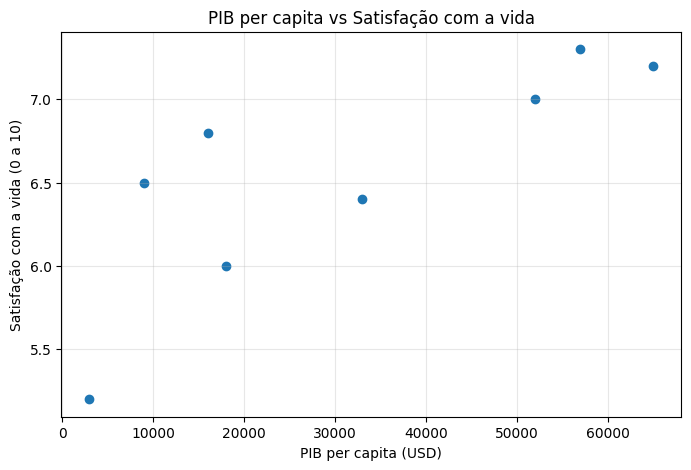

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df_csv["GDP_per_capita"], df_csv["Life_satisfaction"])
plt.xlabel("PIB per capita (USD)")
plt.ylabel("Satisfação com a vida (0 a 10)")
plt.title("PIB per capita vs Satisfação com a vida")
plt.grid(True, alpha=0.3)
plt.show()


### 6.1) Colocando rótulos nos pontos (para facilitar a leitura)

Execute:


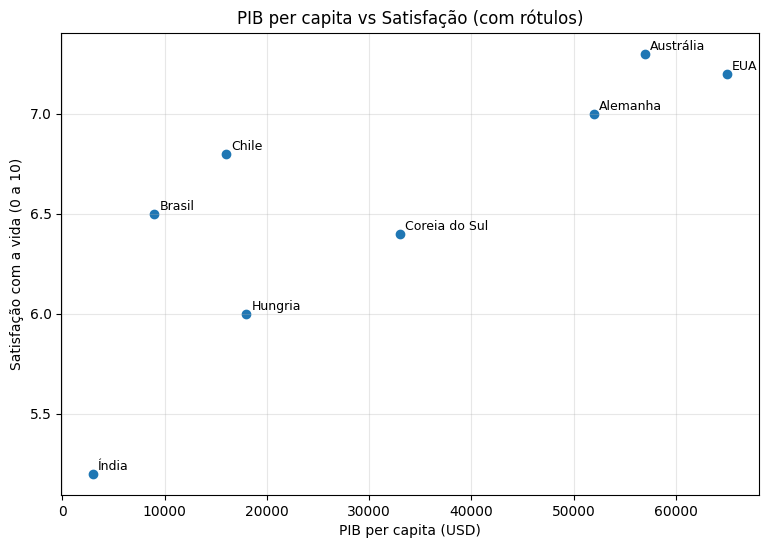

In [10]:
plt.figure(figsize=(9,6))
plt.scatter(df_csv["GDP_per_capita"], df_csv["Life_satisfaction"])

for _, row in df_csv.iterrows():
    plt.text(row["GDP_per_capita"] + 500, row["Life_satisfaction"] + 0.02, row["Country"], fontsize=9)

plt.xlabel("PIB per capita (USD)")
plt.ylabel("Satisfação com a vida (0 a 10)")
plt.title("PIB per capita vs Satisfação (com rótulos)")
plt.grid(True, alpha=0.3)
plt.show()


## 7) Um número para resumir a relação: correlação (sem modelo)

A **correlação** (Pearson) mede o quanto duas variáveis caminham juntas:
- perto de **+1**: crescem juntas
- perto de **-1**: uma sobe e a outra desce
- perto de **0**: pouca relação linear

> Observação: correlação **não** significa causalidade.


In [11]:
corr = df_csv["GDP_per_capita"].corr(df_csv["Life_satisfaction"])
corr


np.float64(0.8043707514151364)

## 8) Procurando possíveis outliers (pontos “fora do padrão”)

Uma forma simples (didática) é olhar para:
- quem tem PIB bem alto, mas satisfação relativamente baixa (ou vice-versa)

Vamos comparar cada país com a média da satisfação.


In [12]:
mean_sat = df_csv["Life_satisfaction"].mean()
df_csv["Sat_minus_mean"] = df_csv["Life_satisfaction"] - mean_sat

df_csv.sort_values("Sat_minus_mean")


,Country,GDP_per_capita,Life_satisfaction,Sat_minus_mean
4,Índia,3000,5.2,-1.35
7,Hungria,18000,6.0,-0.55
6,Coreia do Sul,33000,6.4,-0.15
0,Brasil,9000,6.5,-0.05
3,Chile,16000,6.8,0.25
2,Alemanha,52000,7.0,0.45
1,EUA,65000,7.2,0.65
5,Austrália,57000,7.3,0.75


### 8.1) Visualizando a satisfação acima/abaixo da média

Execute:


In [ ]:
df_plot = df_csv.sort_values("Sat_minus_mean")
cores = ["#e74c3c" if v < 0 else "#2ecc71" for v in df_plot["Sat_minus_mean"]]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(df_plot["Country"], df_plot["Sat_minus_mean"], color=cores, edgecolor="white", linewidth=0.8)

# Valor numérico em cada barra
for bar, val in zip(bars, df_plot["Sat_minus_mean"]):
    offset = 0.03 if val >= 0 else -0.06
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f"{val:+.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("Satisfação com a vida: desvio em relação à média global", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Diferença (pontos)", fontsize=10)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# Legenda manual
from matplotlib.patches import Patch
legenda = [Patch(color="#2ecc71", label="Acima da média"), Patch(color="#e74c3c", label="Abaixo da média")]
ax.legend(handles=legenda, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()


## 9) Conclusões (sem “fechar questão”)

Responda em texto (no seu caderno ou aqui):

1. A relação parece existir? Por quê?
2. Se existe, ela é forte ou fraca?
3. Há países que fogem do padrão? Quais?
4. Que **outros fatores** poderiam influenciar satisfação, além de PIB?

> **Ponto-chave:** dados ajudam a investigar, mas uma análise responsável considera limitações e contexto.


## 10) Extensões sugeridas (para quando você quiser evoluir o notebook)

Sem mudar a estrutura, você pode evoluir assim:
- Substituir o CSV por dados reais (OCDE/FMI)
- Adicionar mais variáveis (saúde, segurança, desigualdade, etc.)
- Discutir “dados insuficientes” e “dados não representativos”
- Só depois: introduzir um modelo simples (regressão) e treino/teste

Se você quiser, eu gero uma **versão-aluno** (com lacunas) e uma **versão-professor** (com comentários e gabarito de discussões).
